In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
car_data = './Python/car_prices.csv'

1. Wczytywanie i podstawa: Wczytaj plik car_prices.csv. Wyświetl podstawowe informacje o zbiorze (df.info()) oraz sprawdź, ile jest brakujących wartości w każdej kolumnie.


In [147]:
df = pd.read_csv(car_data)

2. Czyszczenie danych: Usuń ze zbioru wszystkie wiersze, w których brakuje nazwy marki (make) lub modelu (model). Wyświetl informację, ile wierszy pozostało po tym zabiegu.

In [148]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df.isna().sum()

year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
dtype: int64

3. Statystyki opisowe: Oblicz średnią, minimalną oraz maksymalną cenę sprzedaży (sellingprice) dla całego zbioru danych.

In [149]:
print(f'Maksymalna cena sprzedazy: $ {df['sellingprice'].max()}')
print(f'Minimalmna cena sprzedazy: $ {df['sellingprice'].min()}')
print(f'Srednia cena sprzedazy: $ {round(df['sellingprice'].mean(),2)}')

Maksymalna cena sprzedazy: $ 230000.0
Minimalmna cena sprzedazy: $ 1.0
Srednia cena sprzedazy: $ 13690.51


In [150]:
df[['make','model','year','sellingprice']].loc[df['sellingprice']<=100].sort_values(by=['year','sellingprice'],ascending=True)
# mamy tu outliery, gdzie samochody sa sprzedawane za cene ponizej 100$ - co jest bardzo skrajna wartoscia

,make,model,year,sellingprice
357662,BMW,3 Series,1995,100.0
198458,Mitsubishi,Galant,1997,100.0
167048,Chrysler,Sebring,2002,100.0
356163,Dodge,Durango,2002,100.0
31471,Mercedes-Benz,E-Class,2003,1.0
16207,Chevrolet,Malibu,2003,100.0
233641,Nissan,Altima,2003,100.0
379449,Chevrolet,Impala,2003,100.0
158959,Pontiac,Montana,2004,100.0
343068,Hyundai,Elantra,2005,100.0


4. Filtrowanie roczników: Stwórz nowy DataFrame o nazwie df_modern, który będzie zawierał tylko samochody wyprodukowane w roku 2010 lub nowsze.

In [151]:
df_modern = df[df['year']>=2010]
df_modern.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


5. Grupowanie według marki: Pogrupuj dane według marki (make) i oblicz średnią cenę sprzedaży dla każdej z nich. Posortuj wynik od najdroższych marek do najtańszych.

In [152]:
df_grouped = df_modern.groupby('make').agg({'sellingprice':'mean'}).sort_values(by='sellingprice',ascending=False).head(15).reset_index()
df_grouped

,make,sellingprice
0,Rolls-Royce,153456.250000
1,Ferrari,135500.000000
2,Bentley,119298.076923
3,Aston Martin,98750.000000
4,Maserati,67286.363636
5,Tesla,67054.347826
6,Porsche,56308.167951
7,Fisker,46461.111111
8,Land Rover,42641.722595
9,Jaguar,36917.038889


6. Najwięksi sprzedawcy: Znajdź 5 sprzedawców (seller), którzy wystawili najwięcej samochodów w tym zbiorze danych.

In [159]:
df_top5 = df.groupby('seller').agg('make').count().sort_values(ascending=False).head(5)
df_top5

seller
ford motor credit company llc    17756
the hertz corporation            16286
nissan-infiniti lt               15777
santander consumer               14245
avis corporation                 11471
Name: make, dtype: int64

7. Stan a cena: Oblicz średnią cenę sprzedaży w zależności od stanu technicznego (condition).

In [154]:
df.groupby('condition').agg('sellingprice').mean().round(2)

condition
1.0      4111.26
2.0      5829.78
3.0     12514.41
4.0     17621.00
5.0     24582.62
11.0     4706.20
12.0     3909.59
13.0     3381.08
14.0     3292.67
15.0     4043.97
16.0     4556.62
17.0     4354.78
18.0     4603.36
19.0     5109.32
21.0     7308.00
22.0     7630.03
23.0     8042.68
24.0     8307.44
25.0     8814.56
26.0     9120.05
27.0     9626.72
28.0    10084.07
29.0    10651.45
31.0    11596.35
32.0    11784.98
33.0    12144.13
34.0    12657.39
35.0    13290.61
36.0    13964.99
37.0    14786.36
38.0    15357.55
39.0    15893.33
41.0    17138.33
42.0    17791.51
43.0    18408.09
44.0    19118.50
45.0    19892.98
46.0    20366.42
47.0    20881.72
48.0    21377.92
49.0    22686.27
Name: sellingprice, dtype: float64

8. Kolorystyka: Sprawdź, jakie kolory (color) występują w zbiorze i ile aut ma dany kolor. Który kolor jest najpopularniejszy?

In [155]:
df_color = df['color'].value_counts(ascending=False)
print(f'Najpopularniejszy kolor to {df_color.idxmax()}, suma samochodow w tym kolorze to {df_color.max()}')

Najpopularniejszy kolor to black, suma samochodow w tym kolorze to 93244


9. Różnica rynkowa: Stwórz nową kolumnę o nazwie price_diff, która będzie różnicą między ceną sprzedaży (sellingprice) a wartością rynkową (mmr). Oblicz średnią tej różnicy dla całego zbioru (czy ludzie zazwyczaj przepłacają, czy kupują poniżej wartości?).

In [156]:
df['price_diff']=df['sellingprice']-df['mmr']
df['price_diff'].mean().round(2)

print(f'Ludzie zazwyczaj sprzedaja samochody drozej niz ich wartosc rynkowa (mmr), srednia roznica to $ {round(df['price_diff'].mean(),2)}')

Ludzie zazwyczaj sprzedaja samochody drozej niz ich wartosc rynkowa (mmr), srednia roznica to $ -146.55


10. Wizualizacja (Wyzwanie): Stwórz wykres słupkowy (bar chart) przedstawiający liczbę sprzedanych aut w 10 stanach (state), które pojawiają się najczęściej.
Wymóg: Użyj stylu „architekta” (fig, ax = plt.subplots()).
Wymóg: Dodaj tytuł, opisy osi i zmień kolor słupków na swój ulubiony.

In [157]:
df_top10 = df.groupby('state')['state'].count().sort_values(ascending=False).head(10)

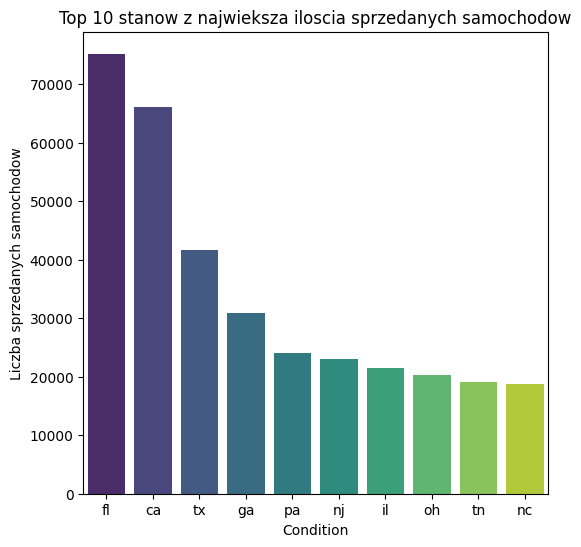

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
sns.barplot(x=df_top10.index,
            y=df_top10.values,
            hue = df_top10.index,
            palette='viridis')
plt.title('Top 10 stanow z najwieksza iloscia sprzedanych samochodow')
plt.xlabel('Condition')
plt.ylabel('Liczba sprzedanych samochodow')
plt.show()